In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import plotnine as p9
from sqlalchemy import create_engine, text

USERNAME = "ssubrahmanya"
DATAFOLDER = Path("../data/")
SEED = 42

engine = create_engine(
    f"mysql://{USERNAME}@/{USERNAME}?charset=utf8mb4",
    connect_args={
        "read_default_file": str(Path.home() / ".my.cnf")
    }
)

/tmp/ipykernel_109930/1320308665.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## Prepare data splits

In [3]:
message_table = "lead_en"
lead_en = pd.read_sql(f"SELECT * FROM {message_table}", engine)

train = lead_en \
    .sample(
        frac=0.6, 
        random_state=SEED
    )

train.to_sql(
    name=f"{message_table}_train", 
    con=engine, 
    if_exists="replace", 
    index=False
)  

sample = lead_en.drop(train.index)
valid = sample \
    .sample(
        frac=0.5, 
        random_state=SEED
    )

valid.to_sql(
        name=f"{message_table}_valid", 
        con=engine, 
        if_exists="replace", 
        index=False
    )

test = sample.drop(valid.index)
test.to_sql(
        name=f"{message_table}_test", 
        con=engine, 
        if_exists="replace", 
        index=False
    )

with engine.connect() as conn:
    conn.execute(text(f"ALTER TABLE {message_table}_train ADD PRIMARY KEY (message_id)"))
    conn.execute(text(f"ALTER TABLE {message_table}_valid ADD PRIMARY KEY (message_id)"))
    conn.execute(text(f"ALTER TABLE {message_table}_test ADD PRIMARY KEY (message_id)"))

print(f"train: {len(train)}, valid: {len(valid)}, test: {len(test)}")

train: 1175, valid: 392, test: 391


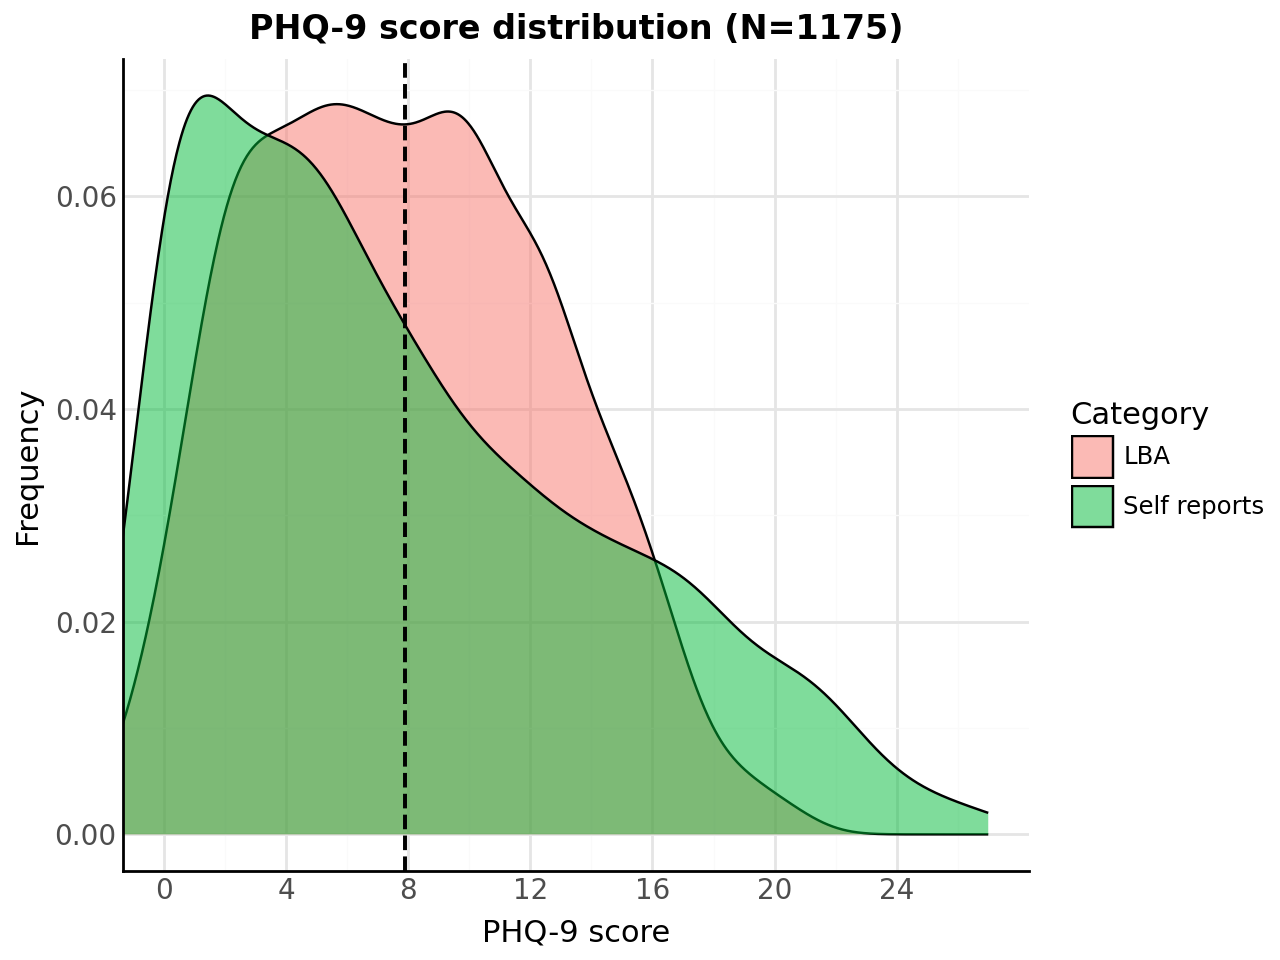

In [2]:
message_table = "lead_en"
lead_en_train = pd.read_sql(f"SELECT message_id, phq9 FROM {message_table}_train", engine)
phq9_pred = pd.read_sql(
    "SELECT group_id AS message_id, value AS phq9_pred "
    "FROM `feat$p_ridg_phq9_pred$lead_en_train$message_id` WHERE feat = 'phq9'",
    engine,
)

LP = pd \
    .merge(
        lead_en_train,
        phq9_pred,
        on="message_id",
        how="inner"
    ) \
    .rename(columns={"phq9": "Self reports", "phq9_pred": "LBA"}) \
    .melt(
        id_vars=["message_id"],
        value_vars=["Self reports", "LBA"],
        var_name="type",
        value_name="value"
    )

means = (
        LP.groupby("type", as_index=False)["value"]
        .mean()
        .rename(columns={"value": "mean"})
    )

(
    p9.ggplot(LP, p9.aes(x="value", fill="type")) + 
    p9.geom_density(
        color="black",
        alpha=0.5,
    ) +
    p9.geom_vline(
        means,
        p9.aes(xintercept="mean"),
        linetype="dashed",
        size=0.8,
    ) +
    p9.scale_x_continuous(breaks=np.arange(0, 28, 4)) +
    p9.scale_fill_manual(values=["#F8766D", "#00BA38"]) +
    p9.coord_cartesian(xlim=(0, 27)) +
    p9.labs(
        x="PHQ-9 score",
        y="Frequency",
        fill="Category",
        title=f"PHQ-9 score distribution (N={LP['message_id'].nunique()})"
    ) +
    p9.theme_minimal() +
    p9.theme(
        axis_line=p9.element_line(color="black"),
        axis_text=p9.element_text(size=10),
        plot_title=p9.element_text(size=12, face="bold"),
    )
)

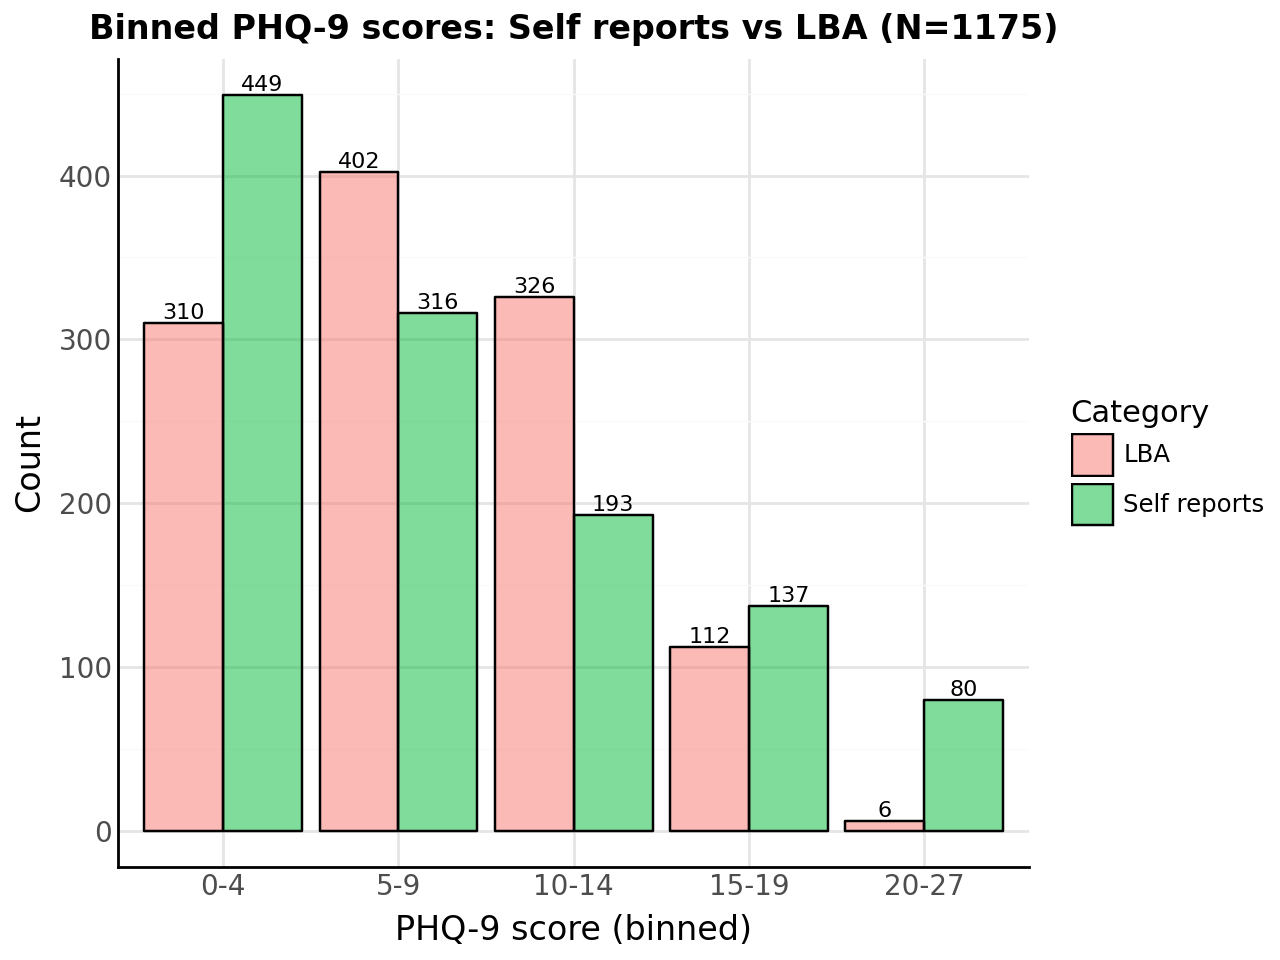

In [3]:
bin_labels = ["0-4", "5-9", "10-14", "15-19", "20-27"]
binned_scores = LP.copy()
binned_scores["bin"] = pd.cut(
    binned_scores["value"],
    bins=[-0.5, 4.5, 9.5, 14.5, 19.5, 27.5],
    labels=bin_labels,
)

binned = (
    binned_scores.groupby(["type", "bin"], observed=False)
    .size()
    .reset_index(name="count")
)
binned["bin"] = pd.Categorical(binned["bin"], categories=bin_labels, ordered=True)

(
    p9.ggplot(binned, p9.aes(x="bin", y="count", fill="type")) + 
    p9.geom_col(
        position="dodge", 
        color="black", 
        alpha=0.5
    ) + 
    p9.geom_text(
        p9.aes(label="count"),
        position=p9.position_dodge(width=0.9),
        va="bottom",
        size=8,
    ) + 
    p9.scale_fill_manual(values=["#F8766D", "#00BA38"]) +
    p9.labs(
        x="PHQ-9 score (binned)",
        y="Count",
        fill="Category",
        title=f"Binned PHQ-9 scores: Self reports vs LBA (N={LP['message_id'].nunique()})",
    ) + 
    p9.theme_minimal() + 
    p9.theme(
        axis_line=p9.element_line(color="black"),
        axis_title=p9.element_text(size=12),
        axis_text=p9.element_text(size=10),
        plot_title=p9.element_text(size=12, face="bold"),
    )
)

In [4]:
SCALE_CONFIG = {
    "phq9": {
        "name": "PHQ-9",
        "gt_col": "phq9",
        "feat": "phq9",
        "responses_table": "responses_phq9",
        "axis_label": "PHQ-9 score",
        "x_breaks": range(0, 28, 4),
        "x_limits": (0, 27),
        "bin_edges": [-0.5, 4.5, 9.5, 14.5, 19.5, 27.5],
        "bin_labels": ["0-4", "5-9", "10-14", "15-19", "20-27"],
    },
    "gad7": {
        "name": "GAD-7",
        "gt_col": "gad7",
        "feat": "gad7",
        "responses_table": "responses_gad7",
        "axis_label": "GAD-7 score",
        "x_breaks": range(0, 22, 3),
        "x_limits": (0, 21),
        "bin_edges": [-0.5, 4.5, 9.5, 14.5, 21.5],
        "bin_labels": ["0-4", "5-9", "10-14", "15-21"],
    },
    "pss10": {
        "name": "PSS-10",
        "gt_col": "pss10",
        "feat": "pss10",
        "responses_table": "responses_pss10",
        "axis_label": "PSS-10 score",
        "x_breaks": range(0, 41, 5),
        "x_limits": (0, 40),
        "bin_edges": [-0.5, 13.5, 26.5, 40.5],
        "bin_labels": ["0-13", "14-26", "27-40"],
    },
}

# An LLM response is identified by (scale, strategy, model). The two prompting
# strategies (vanilla = prompts/prompt.py, vignette = prompts/vignette.py) and
# the model live as the `variant`/`model` columns of responses_<scale>.
VARIANTS = ["vanilla", "vignette"]
SOURCE_ORDER = ["Ground Truth", "Human LBA", "LLM LBA"]
# Default ggplot hue palette, matching the earlier self-report (red) vs LBA
# (green) plots; LLM LBA takes the third hue.
SOURCE_COLORS = {
    "Ground Truth": "#F8766D",
    "Human LBA": "#00BA38",
    "LLM LBA": "#619CFF",
}
SCALE_ORDER = [cfg["name"] for cfg in SCALE_CONFIG.values()]


def load_llm_language_scores() -> pd.DataFrame:
    """Long-format LBA (language-based assessment) scores for every LLM-generated
    response, stacked across all scales, prompting strategies, and models.

    Columns: message_id, scale, strategy, model, score.

    The LBA prediction table is keyed by responses_<scale>'s *surrogate*
    message_id (vignette rows are offset by +100000000), so we join back through
    responses_<scale> to recover the source record id, the prompt variant, and
    the model -- a plain join on message_id would silently drop every vignette
    row.
    """
    frames = []
    for cfg in SCALE_CONFIG.values():
        df = pd.read_sql(
            f"SELECT r.source_message_id AS message_id, r.variant AS strategy, "
            f"r.model AS model, p.value AS score "
            f"FROM `feat$p_ridg_{cfg['feat']}_pred${cfg['responses_table']}$message_id` p "
            f"JOIN {cfg['responses_table']} r ON r.message_id = p.group_id "
            f"WHERE p.feat = '{cfg['feat']}'",
            engine,
        )
        df["scale"] = cfg["name"]
        frames.append(df)

    long = pd.concat(frames, ignore_index=True)
    long["scale"] = pd.Categorical(long["scale"], categories=SCALE_ORDER, ordered=True)
    long["strategy"] = pd.Categorical(long["strategy"], categories=VARIANTS, ordered=True)
    return long[["message_id", "scale", "strategy", "model", "score"]]


def load_human_language_scores() -> pd.DataFrame:
    """Long-format Human LBA scores -- the same ridge model applied to each
    participant's *own* writing -- stacked across all scales.

    Columns: message_id, scale, score. No strategy/model: there is a single
    human-text source per record.
    """
    frames = []
    for cfg in SCALE_CONFIG.values():
        df = pd.read_sql(
            f"SELECT group_id AS message_id, value AS score "
            f"FROM `feat$p_ridg_{cfg['feat']}_pred$lead_en_valid$message_id` "
            f"WHERE feat = '{cfg['feat']}'",
            engine,
        )
        df["scale"] = cfg["name"]
        frames.append(df)

    long = pd.concat(frames, ignore_index=True)
    long["scale"] = pd.Categorical(long["scale"], categories=SCALE_ORDER, ordered=True)
    return long[["message_id", "scale", "score"]]


def load_human_self_reports() -> pd.DataFrame:
    """Long-format self-report ground-truth scores from the validation split,
    stacked across all scales.

    Columns: message_id, scale, score. No strategy/model: this is the measured
    ground truth per record.
    """
    frames = []
    for cfg in SCALE_CONFIG.values():
        df = pd.read_sql(
            f"SELECT message_id, {cfg['gt_col']} AS score FROM lead_en_valid",
            engine,
        )
        df["scale"] = cfg["name"]
        frames.append(df)

    long = pd.concat(frames, ignore_index=True)
    long["scale"] = pd.Categorical(long["scale"], categories=SCALE_ORDER, ordered=True)
    return long[["message_id", "scale", "score"]]

In [5]:
def build_density_plot(scale):
    """Faceted density plot for a single scale, comparing the three measurement
    sources in each (strategy, model) cell.

    The LLM scores carry their own (strategy, model); the two human references
    have neither, so we cross-join them into every (strategy, model) cell the
    LLM was run for -- giving each facet its Ground Truth / Human LBA baseline.
    """
    cfg = SCALE_CONFIG[scale]
    name = cfg["name"]

    llm = load_llm_language_scores()
    human_lba = load_human_language_scores()
    self_report = load_human_self_reports()

    # Keep only the requested scale.
    llm = llm[llm["scale"] == name].assign(source="LLM LBA")
    human_lba = human_lba[human_lba["scale"] == name].assign(source="Human LBA")
    self_report = self_report[self_report["scale"] == name].assign(source="Ground Truth")

    combos = llm[["strategy", "model"]].drop_duplicates()
    refs = (
        pd.concat([self_report, human_lba], ignore_index=True)
        .merge(combos, how="cross")
    )

    long = pd.concat([refs, llm], ignore_index=True)
    long["source"] = pd.Categorical(long["source"], categories=SOURCE_ORDER, ordered=True)
    long["strategy"] = pd.Categorical(long["strategy"], categories=VARIANTS, ordered=True)

    means = (
        long.groupby(["source", "strategy", "model"], as_index=False, observed=True)["score"]
        .mean()
        .rename(columns={"score": "mean"})
    )

    plot = (
        p9.ggplot(long, p9.aes(x="score", fill="source"))
        + p9.geom_density(alpha=0.4, color="black")
        + p9.geom_vline(
            means,
            p9.aes(xintercept="mean", color="source", linetype="source"),
            size=0.8,
        )
        + p9.scale_fill_manual(values=SOURCE_COLORS)
        + p9.scale_color_manual(values=SOURCE_COLORS)
        + p9.scale_x_continuous(breaks=cfg["x_breaks"])
        + p9.coord_cartesian(xlim=cfg["x_limits"])
        + p9.facet_grid("model ~ strategy")
        + p9.labs(
            x=cfg["axis_label"],
            y="Density",
            fill="Source",
            color="Source",
            linetype="Source",
            title=name,
        )
        + p9.theme_minimal()
        + p9.theme(
            axis_line=p9.element_line(color="black"),
            axis_title=p9.element_text(size=12),
            axis_text=p9.element_text(size=10),
            plot_title=p9.element_text(size=11, face="bold"),
        )
    )

    return plot

In [6]:
def build_binned_plot():
    # Bin each scale on its own edges, then stack. A single global category
    # order (scale order, de-duplicated) keeps every facet's bars left-to-right;
    # free_x drops the labels that don't belong to a given scale column.
    frames, bin_order = [], []
    for cfg in SCALE_CONFIG.values():
        df = load_sources(cfg)
        df["scale"] = cfg["name"]
        df["bin"] = pd.cut(df["score"], bins=cfg["bin_edges"], labels=cfg["bin_labels"])
        frames.append(df)
        bin_order += [b for b in cfg["bin_labels"] if b not in bin_order]

    long = pd.concat(frames, ignore_index=True)
    long["scale"] = pd.Categorical(long["scale"], categories=SCALE_ORDER, ordered=True)

    binned = (
        long.groupby(["source", "strategy", "model", "scale", "bin"], observed=True)
        .size()
        .reset_index(name="count")
    )
    binned["bin"] = pd.Categorical(binned["bin"], categories=bin_order, ordered=True)

    return (
        p9.ggplot(binned, p9.aes(x="bin", y="count", fill="source")) + 
        p9.geom_col(
            position="dodge", 
            color="black", 
            alpha=0.5
        ) + 
        p9.geom_text(
            p9.aes(label="count"),
            position=p9.position_dodge(width=0.9),
            va="bottom",
            size=7,
        ) + 
        p9.facet_grid("strategy + model ~ scale", scales="free_x") +
        p9.labs(x="Score (binned)", y="Count", fill="Source") + 
        p9.theme_minimal() + 
        p9.theme(
            axis_line=p9.element_line(color="black"),
            axis_title=p9.element_text(size=12),
            axis_text=p9.element_text(size=10),
            plot_title=p9.element_text(size=11, face="bold"),
        )
    )

/home/ssubrahmanya/personallm/.venv/lib/python3.12/site-packages/plotnine/scales/scale_linetype.py:45: PlotnineWarning: Using linetype for an ordinal variable is not advised.
/home/ssubrahmanya/personallm/.venv/lib/python3.12/site-packages/plotnine/scales/scale_linetype.py:45: PlotnineWarning: Using linetype for an ordinal variable is not advised.
/home/ssubrahmanya/personallm/.venv/lib/python3.12/site-packages/plotnine/scales/scale_linetype.py:45: PlotnineWarning: Using linetype for an ordinal variable is not advised.


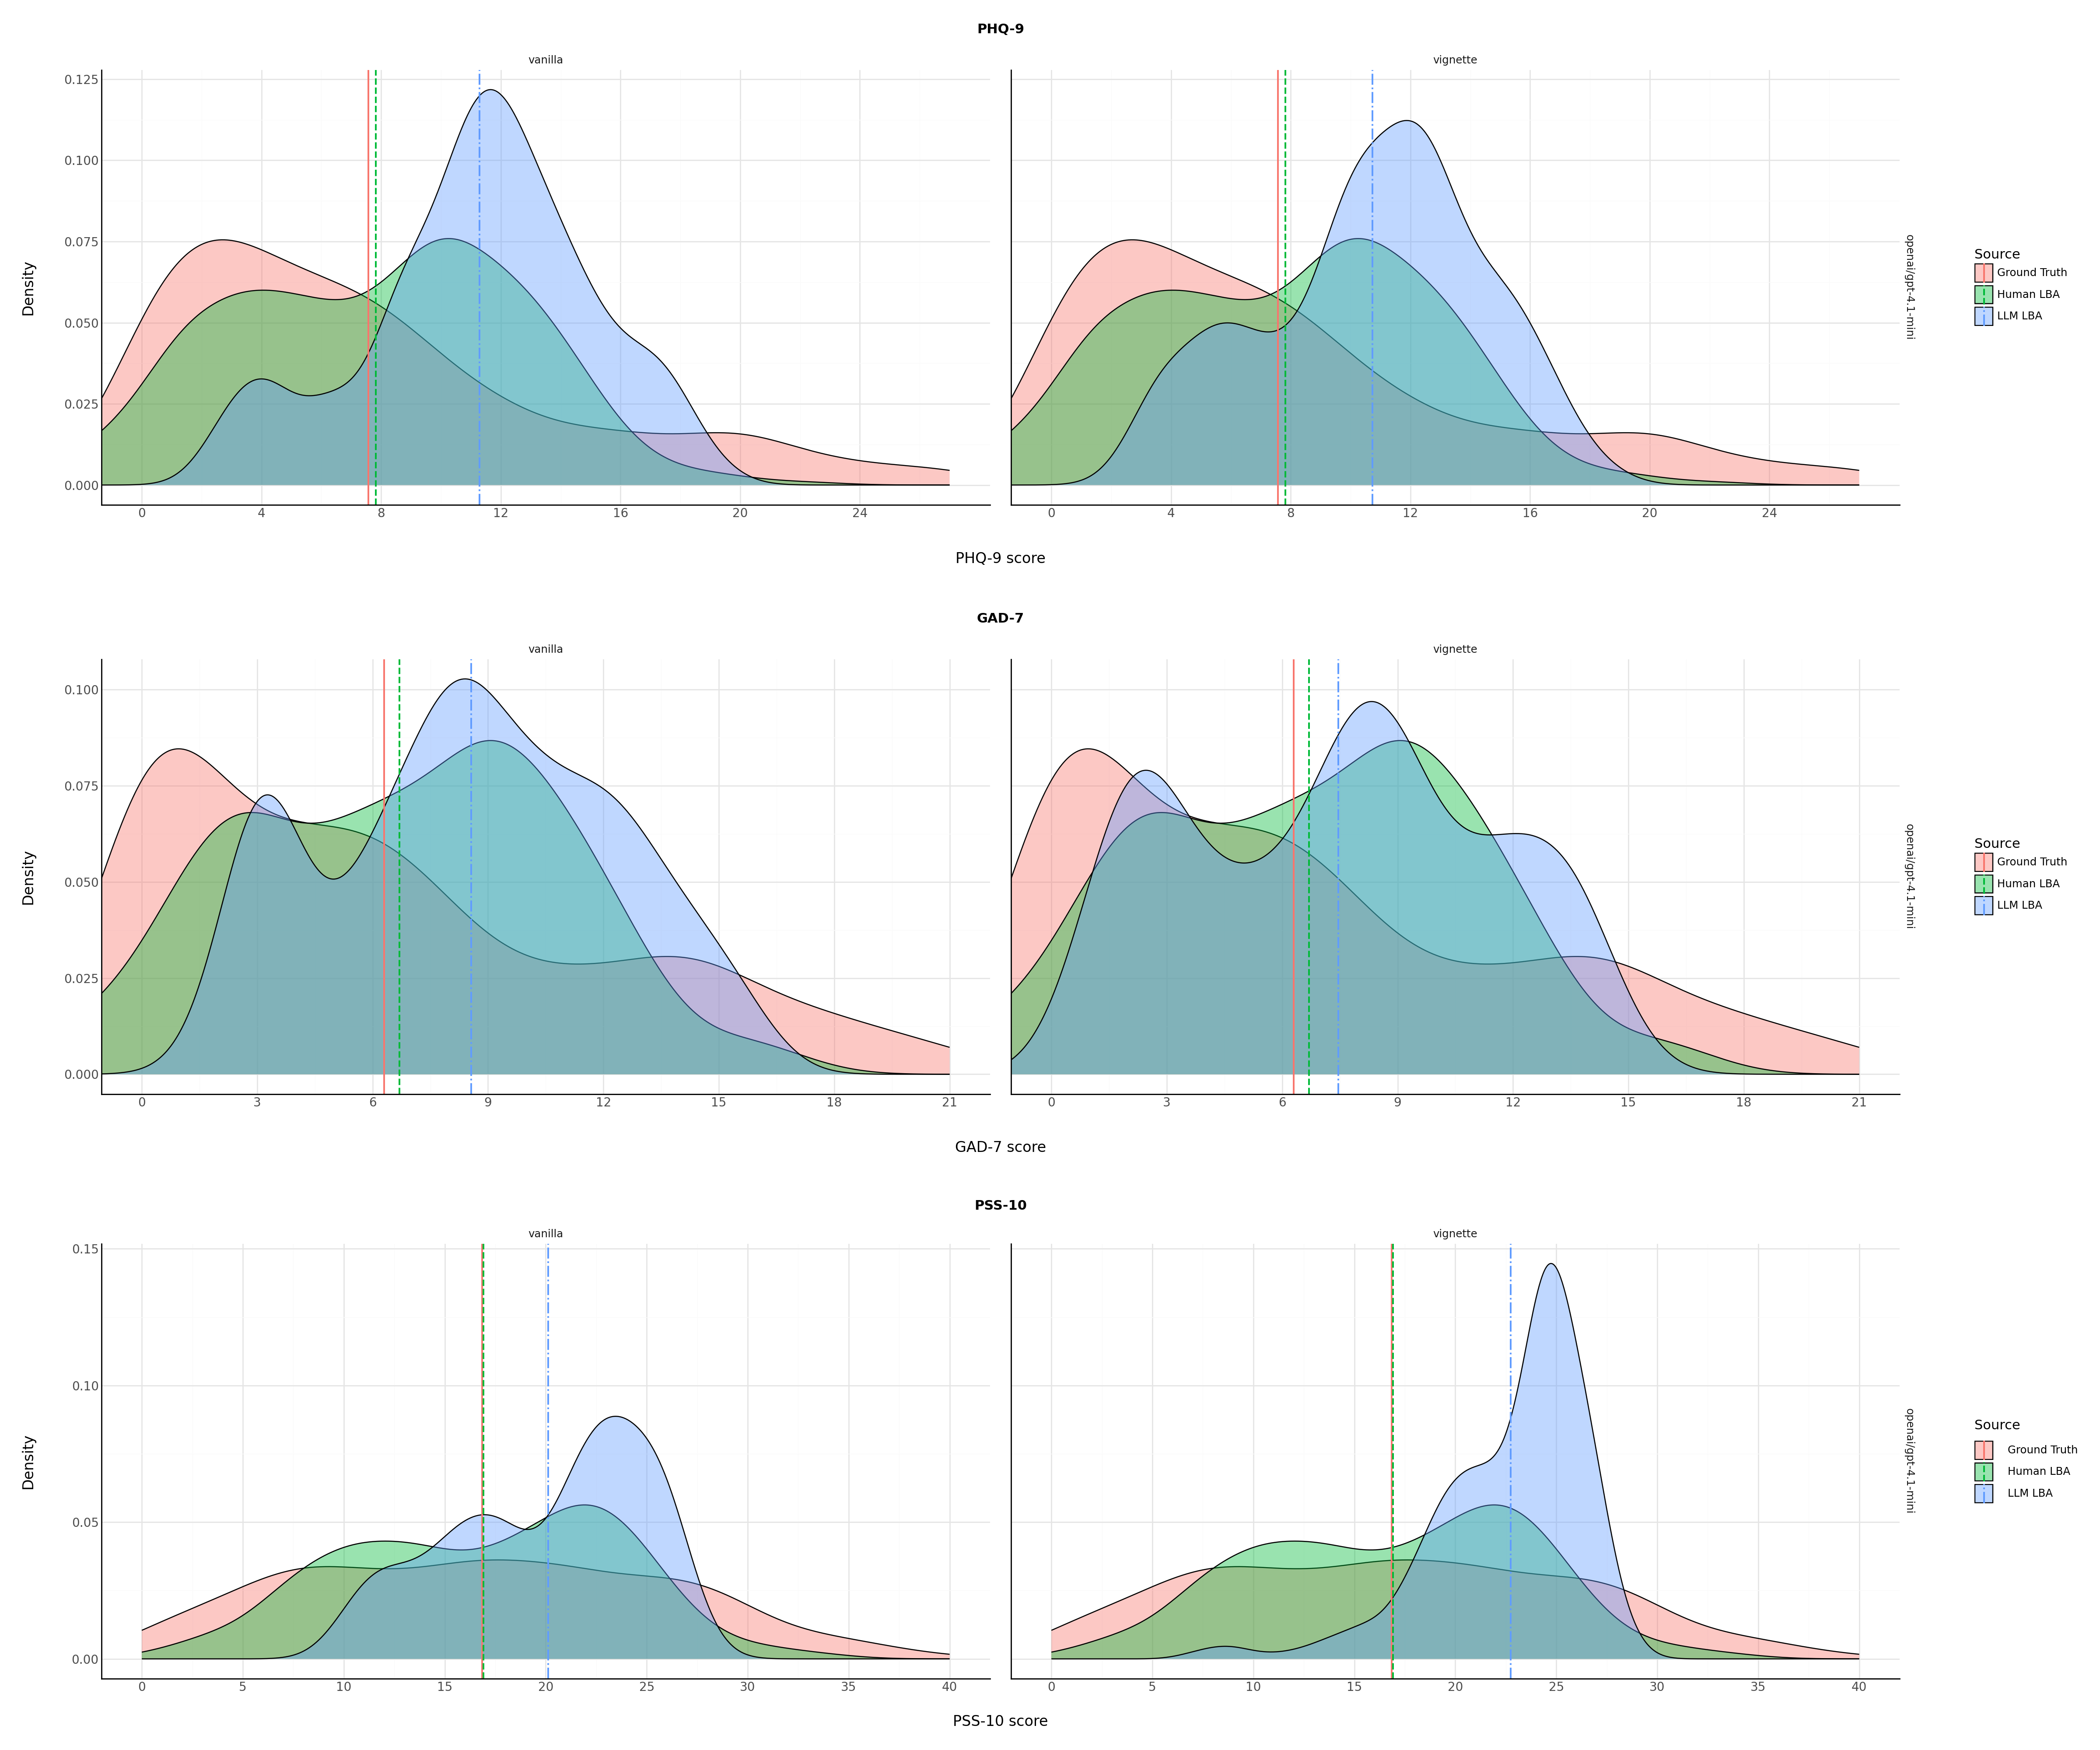

In [7]:
phq9_plot = build_density_plot("phq9")
gad7_plot = build_density_plot("gad7")
pss10_plot = build_density_plot("pss10")

# Each scale is its own (model x strategy)-faceted panel; compose side by side.
(phq9_plot / gad7_plot / pss10_plot) + p9.theme(figure_size=(24, 20))

In [7]:
# FIXME
# test if the variance of the distributions are different -- scale and shape
# another model -- kolmogorov-smirnov test, wasserstein distance, etc.

In [ ]:
build_binned_plot() + p9.theme(figure_size=(20, 9))

In [9]:
# FIXME
# confusion matrix -- for each source of measurement
# 27 x 27 for PHQ-9, 21 x 21 for GAD-7, 40 x 40 for PSS-10

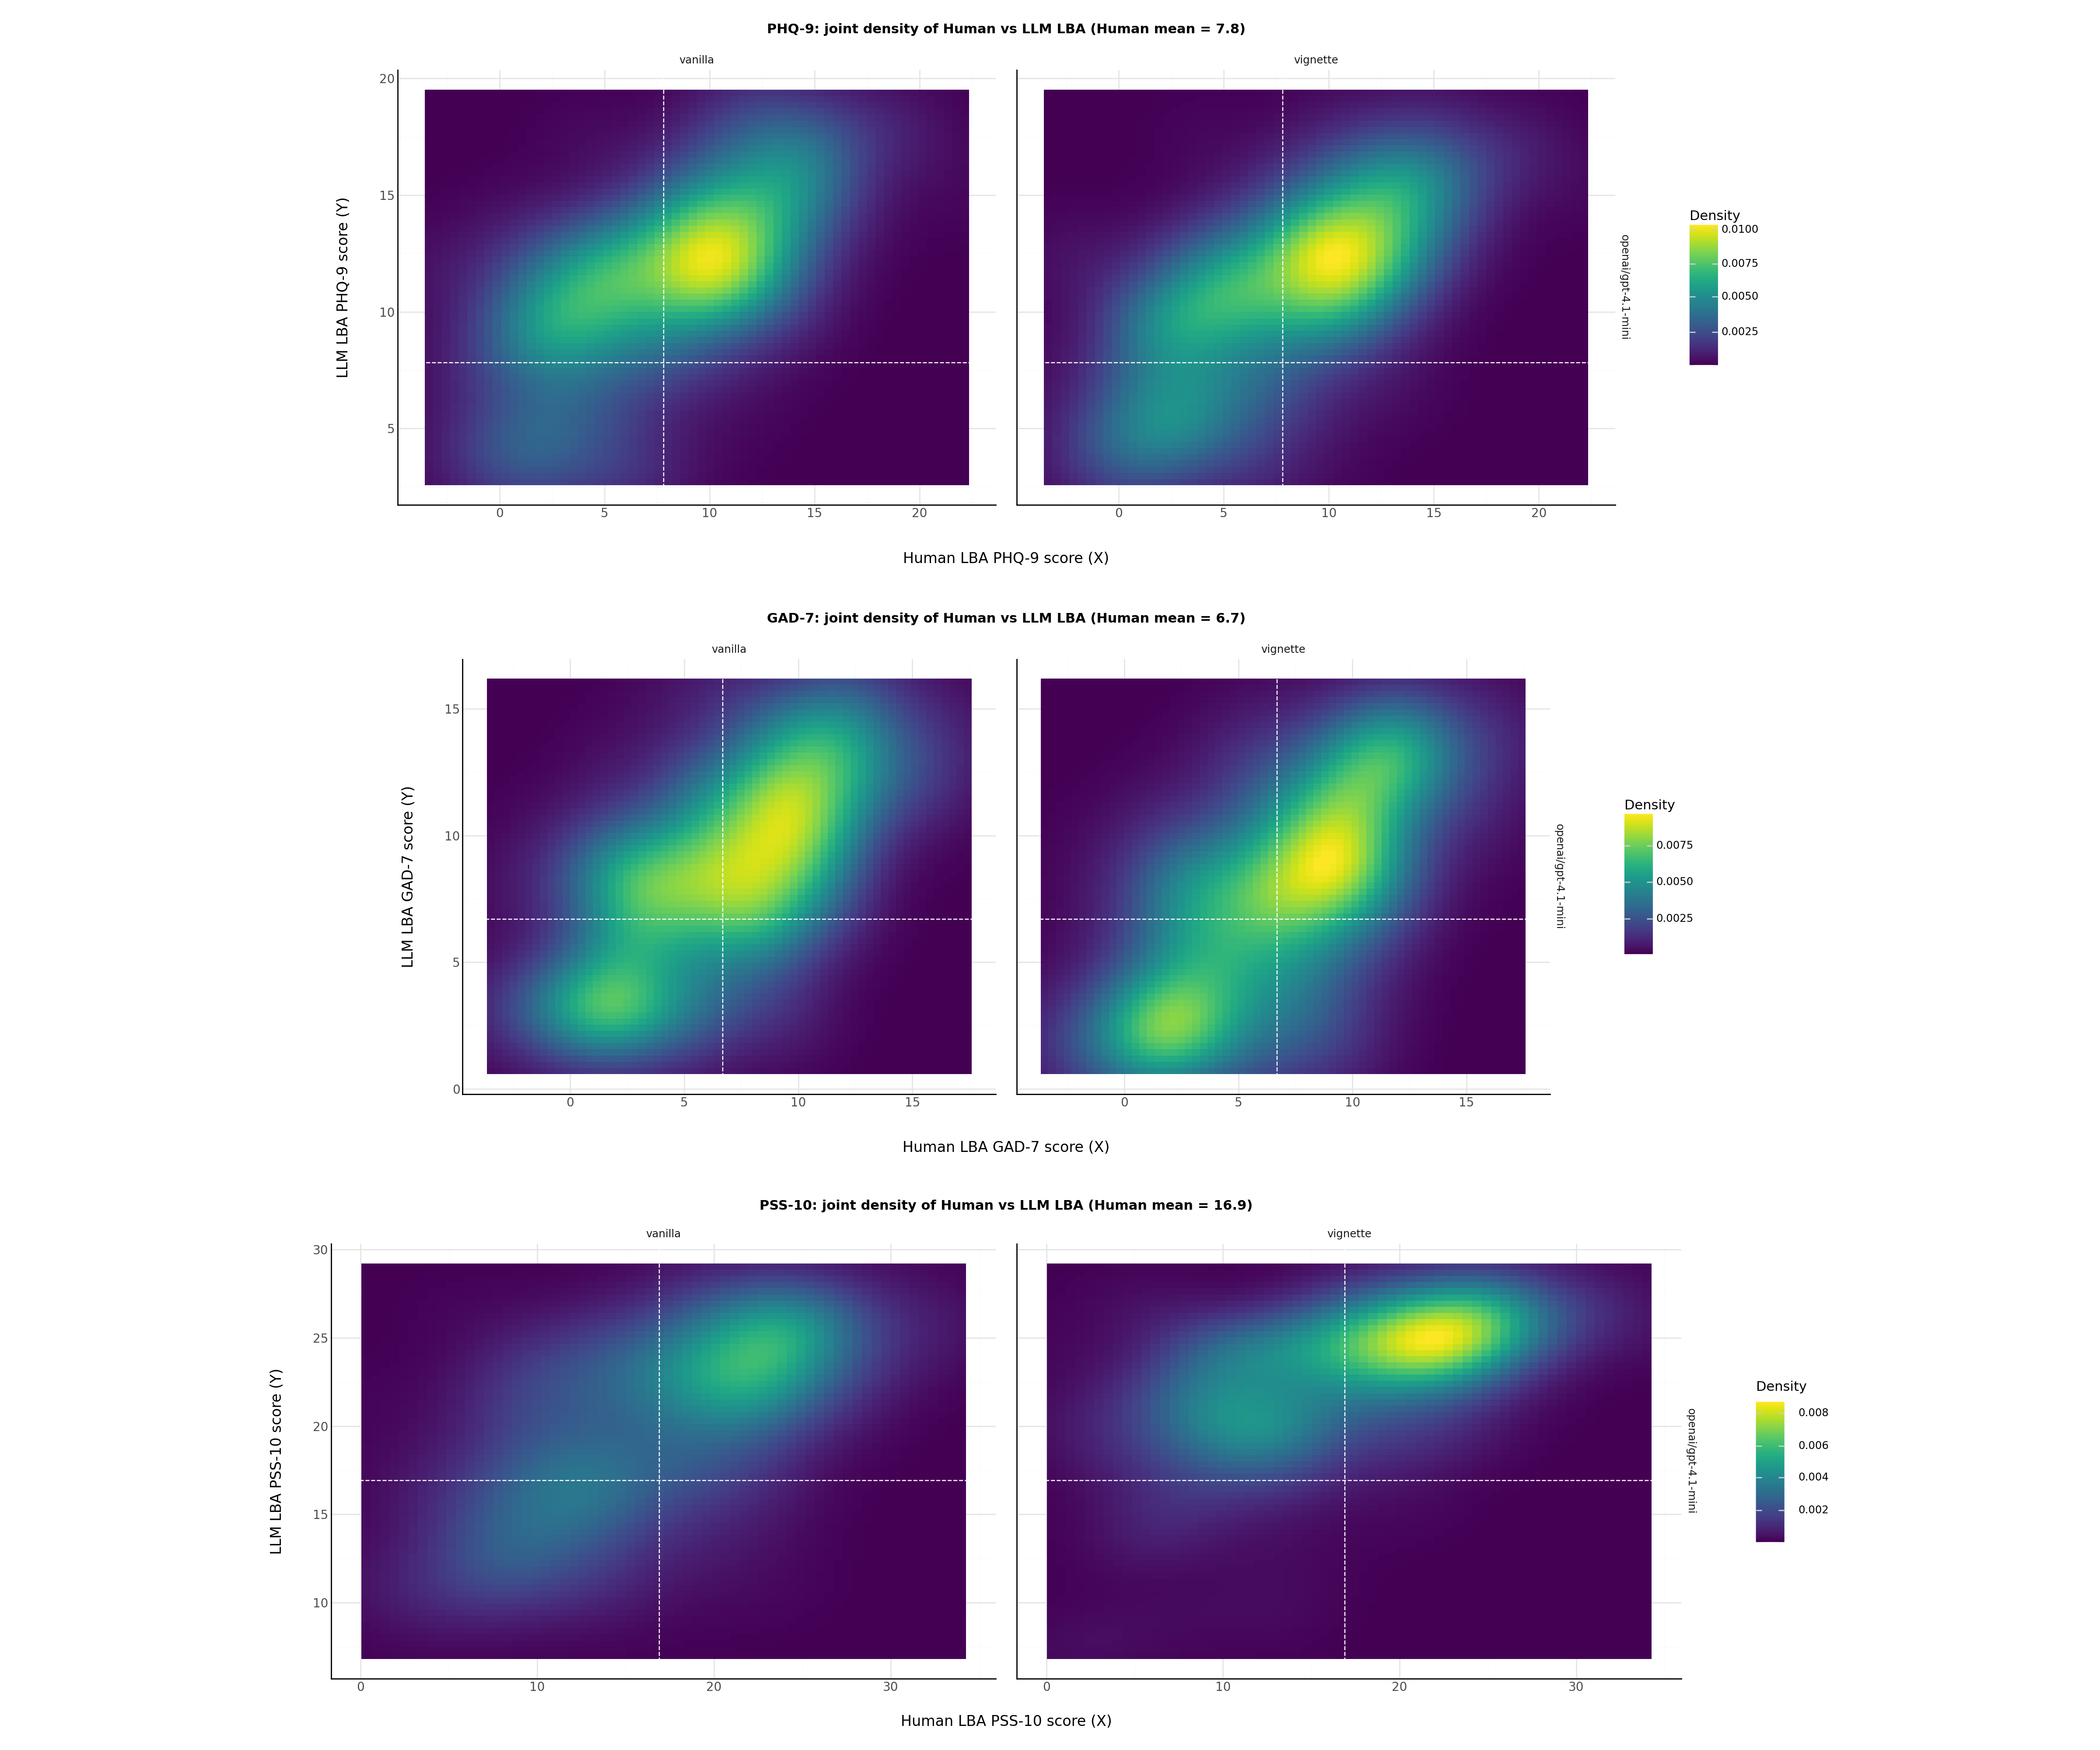

In [8]:
def build_density2_plot(scale: str):
    """2D kernel density of paired Human LBA (x) vs LLM LBA (y) continuous
    scores, faceted by (strategy, model), drawn as a filled raster.

    Both axes are unconstrained ridge predictions on the same score scale, so we
    anchor each facet with the Human LBA mean drawn as both a vertical line (its
    position on X) and a horizontal line (the same value on Y). The LLM density
    mass sitting above the horizontal line is the LLM's mean elevation; mass
    squeezed toward the lines is range compression.
    """
    cfg = SCALE_CONFIG[scale]
    name = cfg["name"]

    human = load_human_language_scores()
    human = human \
        .loc[human["scale"] == name, ["message_id", "score"]] \
        .rename(columns={"score": "x"})

    llm = load_llm_language_scores()
    llm = llm \
        .loc[llm["scale"] == name, ["message_id", "strategy", "model", "score"]] \
        .rename(columns={"score": "y"})

    paired = pd.merge(human, llm, on="message_id", how="inner")

    human_mean = human["x"].mean()

    return (
        p9.ggplot(paired, p9.aes("x", "y"))
        + p9.stat_density_2d(
            p9.aes(fill="..density.."),
            geom="raster",
            contour=False,
        )
        + p9.geom_vline(xintercept=human_mean, linetype="dashed", color="white")
        + p9.geom_hline(yintercept=human_mean, linetype="dashed", color="white")
        + p9.scale_fill_cmap(cmap_name="viridis", name="Density")
        + p9.facet_grid("model ~ strategy")
        + p9.coord_fixed()
        + p9.labs(
            x=f"Human LBA {cfg['axis_label']} (X)",
            y=f"LLM LBA {cfg['axis_label']} (Y)",
            title=f"{name}: joint density of Human vs LLM LBA "
            f"(Human mean = {human_mean:.1f})",
        )
        + p9.theme_minimal()
        + p9.theme(
            axis_line=p9.element_line(color="black"),
            axis_title=p9.element_text(size=12),
            axis_text=p9.element_text(size=10),
            plot_title=p9.element_text(size=11, face="bold"),
        )
    )


phq9_plot = build_density2_plot("phq9")
gad7_plot = build_density2_plot("gad7")
pss10_plot = build_density2_plot("pss10")

(phq9_plot / gad7_plot / pss10_plot) + p9.theme(figure_size=(24, 20))

In [20]:
import statsmodels.formula.api as smf


def fit_attenuation_model(scale: str, variant: str):
    """Fit the LBA attenuation model comparing Human LBA against one LLM prompt
    variant, for one scale.

    Each individual contributes two long-format rows -- one for the Human LBA
    and one for the LLM LBA of ``variant`` -- sharing the same ground-truth
    score, then fits

        predicted = b0 + b1*ground_truth + b2*source + b3*(ground_truth*source) + e

    where ``source`` is a 0/1 indicator (0 = Human LBA, 1 = LLM LBA). b2 is the mean
    shift (elevation) and b3 the extra range compression of that LLM variant
    relative to the human language model. Returns the fitted results object.
    """
    cfg = SCALE_CONFIG[scale]

    gt = pd.read_sql(
        f"SELECT message_id, {cfg['gt_col']} AS ground_truth FROM lead_en_valid",
        engine,
    )
    human_lba = pd.read_sql(
        f"SELECT group_id AS message_id, value AS predicted "
        f"FROM `feat$p_ridg_{cfg['feat']}_pred$lead_en_valid$message_id` "
        f"WHERE feat = '{cfg['feat']}'",
        engine,
    )
    llm_lba = pd.read_sql(
        f"SELECT r.source_message_id AS message_id, p.value AS predicted "
        f"FROM `feat$p_ridg_{cfg['feat']}_pred${cfg['responses_table']}$message_id` p "
        f"JOIN {cfg['responses_table']} r ON r.message_id = p.group_id "
        f"WHERE p.feat = '{cfg['feat']}' AND r.variant = '{variant}'",
        engine,
    )

    human_lba["source"] = "human"
    llm_lba["source"] = "llm"

    # Inner-join each LBA to its ground truth so every individual contributes
    # one row per source, then stack the two sources into long format.
    long = pd.concat(
        [
            gt.merge(human_lba, on="message_id", how="inner"),
            gt.merge(llm_lba, on="message_id", how="inner"),
        ],
        ignore_index=True,
    )

    model = smf.ols("predicted ~ ground_truth * source", data=long)
    results = model.fit()

    return results

In [19]:
from scipy.stats import ks_2samp


def ks_test_lba(scale: str, variant: str):
    """Two-sample Kolmogorov-Smirnov test comparing the Human LBA against one
    LLM prompt variant, for one scale.

    Loads the two marginal distributions of ridge predictions -- Human LBA on
    each participant's own writing, and LLM LBA on the ``variant`` responses --
    then runs ``ks_2samp``. The KS statistic is the maximum gap between the two
    empirical CDFs; a small p-value means the two distributions differ in
    location and/or shape. Returns the scipy result object.
    """
    cfg = SCALE_CONFIG[scale]

    human_lba = pd.read_sql(
        f"SELECT value AS predicted "
        f"FROM `feat$p_ridg_{cfg['feat']}_pred$lead_en_valid$message_id` "
        f"WHERE feat = '{cfg['feat']}'",
        engine,
    )
    llm_lba = pd.read_sql(
        f"SELECT p.value AS predicted "
        f"FROM `feat$p_ridg_{cfg['feat']}_pred${cfg['responses_table']}$message_id` p "
        f"JOIN {cfg['responses_table']} r ON r.message_id = p.group_id "
        f"WHERE p.feat = '{cfg['feat']}' AND r.variant = '{variant}'",
        engine,
    )

    return ks_2samp(human_lba["predicted"], llm_lba["predicted"])


# One KS test per (scale, prompt variant), each comparing that LLM variant's
# LBA distribution against the Human LBA distribution.
ks_results = []
for scale in SCALE_CONFIG:
    for variant in VARIANTS:
        result = ks_test_lba(scale, variant)
        ks_results.append(
            {
                "scale": scale,
                "variant": variant,
                "ks_statistic": result.statistic,
                "pvalue": result.pvalue,
            }
        )
        print(f"{scale} / {variant}: D={result.statistic:.3f}, p={result.pvalue:.2e}")

ks_results = pd.DataFrame(ks_results)
ks_results.round(4)

phq9 / vanilla: D=0.342, p=1.07e-20
phq9 / vignette: D=0.278, p=9.56e-14
gad7 / vanilla: D=0.189, p=1.61e-06
gad7 / vignette: D=0.092, p=7.33e-02
pss10 / vanilla: D=0.242, p=1.64e-10
pss10 / vignette: D=0.431, p=4.38e-33


,scale,variant,ks_statistic,pvalue
0,phq9,vanilla,0.3418,0.0000
1,phq9,vignette,0.2781,0.0000
2,gad7,vanilla,0.1888,0.0000
3,gad7,vignette,0.0918,0.0733
4,pss10,vanilla,0.2423,0.0000
5,pss10,vignette,0.4311,0.0000


In [26]:
def summarise_attenuation(results) -> dict:
    """Pull the decomposition coefficients out of a fitted model."""
    params, pvals = results.params, results.pvalues
    return {
        "b1.scorer_slope": params["ground_truth"],
        "b2.mean_shift": params["source[T.llm]"],
        "b3.llm_extra_compression": params["ground_truth:source[T.llm]"],
        "b3.pvalue": pvals["ground_truth:source[T.llm]"],
        "b1+b3.total_slope": params["ground_truth"] + params["ground_truth:source[T.llm]"],
    }

# One attenuation model per (scale, prompt variant), each comparing that LLM
# variant's LBA against the Human LBA.
attenuation = []
for scale in SCALE_CONFIG:
    for variant in VARIANTS:
        
        row = {}
        print(f"Fitting attenuation model for {scale} / {variant}...")
        results = fit_attenuation_model(scale, variant)

        row["scale"] = scale
        row["variant"] = variant

        summary = summarise_attenuation(results)
        row.update(summary)
        attenuation.append(row)

        print(f"Results for {scale} / {variant}:")
        print(results.summary())
        print("\n" + "="*80 + "\n")

attenuation = pd.DataFrame(attenuation)

Fitting attenuation model for phq9 / vanilla...
Results for phq9 / vanilla:
                            OLS Regression Results                            
Dep. Variable:              predicted   R-squared:                       0.656
Model:                            OLS   Adj. R-squared:                  0.655
Method:                 Least Squares   F-statistic:                     496.7
Date:                Tue, 16 Jun 2026   Prob (F-statistic):          2.06e-180
Time:                        12:43:42   Log-Likelihood:                -1900.6
No. Observations:                 784   AIC:                             3809.
Df Residuals:                     780   BIC:                             3828.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

In [27]:
attenuation.round(2)

,scale,variant,b1.scorer_slope,b2.mean_shift,b3.llm_extra_compression,b3.pvalue,b1+b3.total_slope
0,phq9,vanilla,0.53,3.80,-0.04,0.14,0.49
1,phq9,vignette,0.53,3.25,-0.04,0.13,0.49
2,gad7,vanilla,0.51,1.38,0.08,0.01,0.59
3,gad7,vignette,0.51,-0.11,0.14,0.00,0.65
4,pss10,vanilla,0.55,4.57,-0.08,0.00,0.47
5,pss10,vignette,0.55,9.27,-0.20,0.00,0.34


In [13]:
# Headline performance of each LLM prompt variant against the self-report ground
# truth on the validation split: mean elevation (bias), absolute error, and rank
# fidelity (Pearson r). Human LBA is included as the reference upper bound.
def measurement_performance(scale: str, source: str):
    cfg = SCALE_CONFIG[scale]
    gt = pd.read_sql(
        f"SELECT message_id, {cfg['gt_col']} AS gt FROM lead_en_valid", engine
    )
    if source == "Human LBA":
        pred = pd.read_sql(
            f"SELECT group_id AS message_id, value AS pred "
            f"FROM `feat$p_ridg_{cfg['feat']}_pred$lead_en_valid$message_id` "
            f"WHERE feat = '{cfg['feat']}'",
            engine,
        )
    else:  # source is a prompt variant
        pred = pd.read_sql(
            f"SELECT r.source_message_id AS message_id, p.value AS pred "
            f"FROM `feat$p_ridg_{cfg['feat']}_pred${cfg['responses_table']}$message_id` p "
            f"JOIN {cfg['responses_table']} r ON r.message_id = p.group_id "
            f"WHERE p.feat = '{cfg['feat']}' AND r.variant = '{source}'",
            engine,
        )
    d = gt.merge(pred, on="message_id", how="inner")
    return {
        "n": len(d),
        "bias": (d["pred"] - d["gt"]).mean(),
        "mae": (d["pred"] - d["gt"]).abs().mean(),
        "pearson_r": d["gt"].corr(d["pred"]),
    }


performance = pd.DataFrame(
    {
        f"{scale} / {source}": measurement_performance(scale, source)
        for scale in SCALE_CONFIG
        for source in ["Human LBA", *VARIANTS]
    }
).T
performance.round(3)

,n,bias,mae,pearson_r
phq9 / Human LBA,392.0,0.247,3.433,0.728
phq9 / vanilla,392.0,3.714,4.865,0.846
phq9 / vignette,392.0,3.164,4.473,0.878
gad7 / Human LBA,392.0,0.397,3.312,0.692
gad7 / vanilla,392.0,2.264,3.210,0.914
gad7 / vignette,392.0,1.222,2.349,0.944
pss10 / Human LBA,392.0,0.070,4.907,0.735
pss10 / vanilla,392.0,3.285,5.227,0.886
pss10 / vignette,392.0,5.858,7.337,0.846


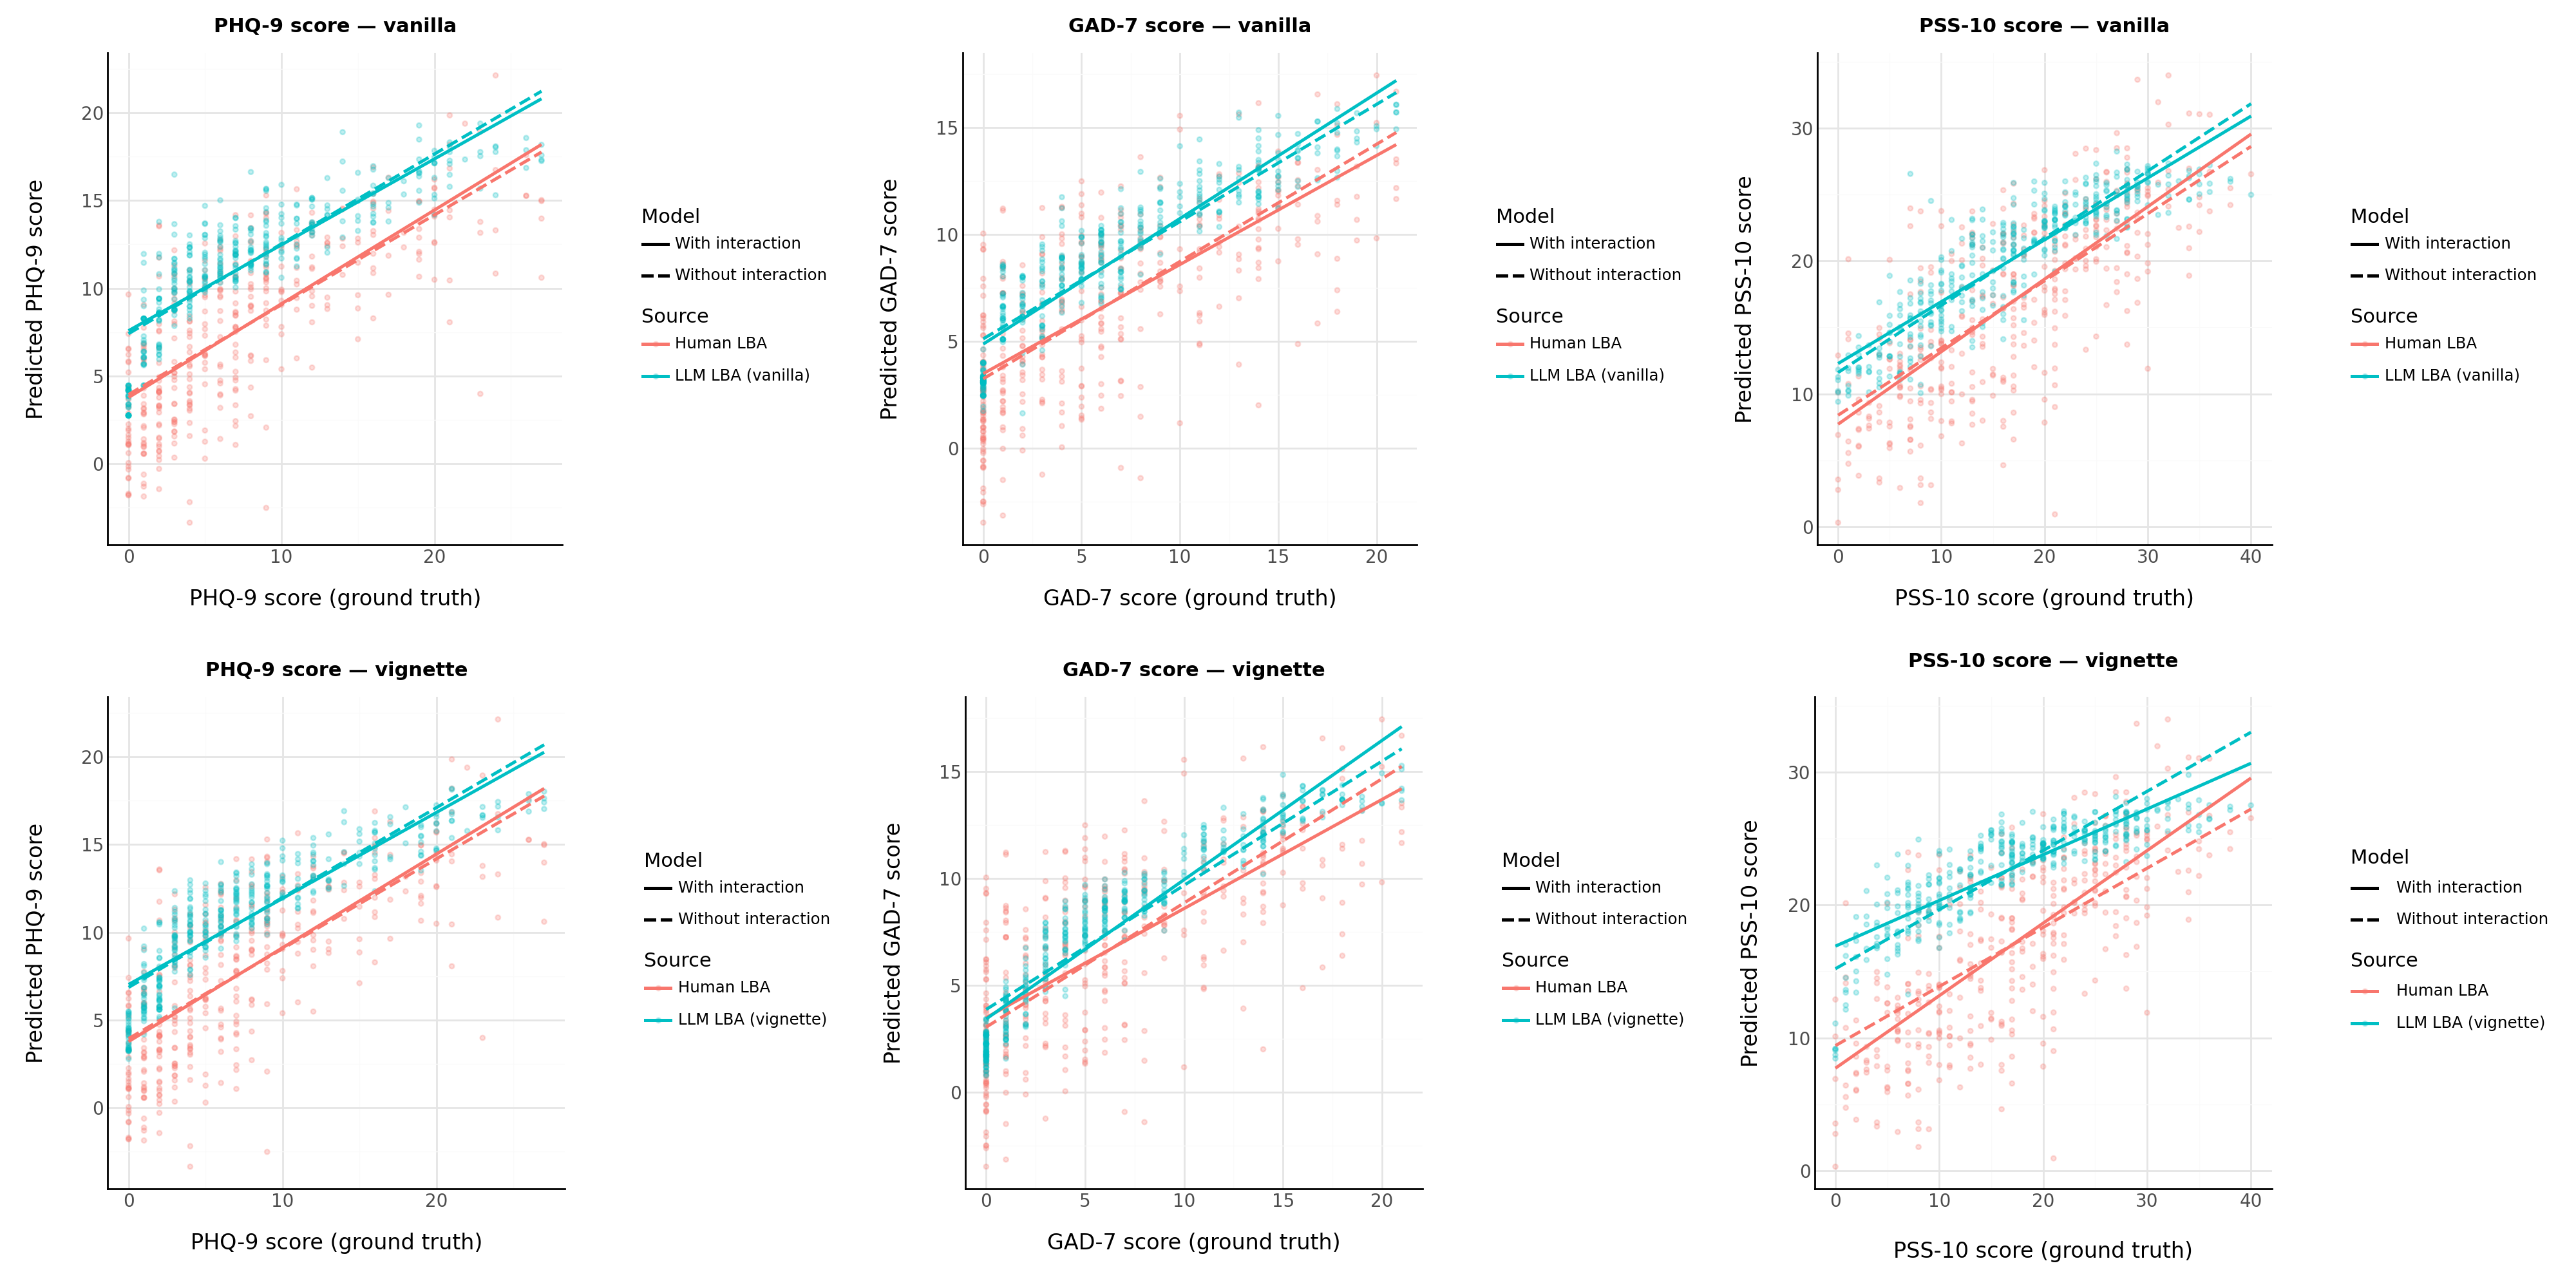

In [14]:
def build_interaction_plot(scale: str, variant: str):
    """Scatter of predicted vs ground truth (Human LBA vs one LLM variant), with
    the interaction model (separate slopes, solid) and the additive model
    (parallel slopes, dashed) overlaid so the effect of the interaction term is
    visible."""
    cfg = SCALE_CONFIG[scale]

    # Reuse the rows the interaction model was fit on; re-fit the additive
    # (no-interaction) model on the exact same data.
    long = models[(scale, variant)].model.data.frame.copy()
    interaction = models[(scale, variant)]
    additive = smf.ols("predicted ~ ground_truth + llm", data=long).fit()

    # Predict both models on a clean ground-truth grid, for each source.
    span = np.linspace(long["ground_truth"].min(), long["ground_truth"].max(), 100)
    grid = pd.DataFrame(
        [(g, llm) for llm in (0, 1) for g in span],
        columns=["ground_truth", "llm"],
    )
    lines = pd.concat(
        [
            grid.assign(predicted=interaction.predict(grid), model="With interaction"),
            grid.assign(predicted=additive.predict(grid), model="Without interaction"),
        ],
        ignore_index=True,
    )

    source_label = {0: "Human LBA", 1: f"LLM LBA ({variant})"}
    long["source"] = long["llm"].map(source_label)
    lines["source"] = lines["llm"].map(source_label)

    return (
        p9.ggplot()
        + p9.geom_point(
            long,
            p9.aes(x="ground_truth", y="predicted", color="source"),
            alpha=0.25,
            size=1,
        )
        + p9.geom_line(
            lines,
            p9.aes(x="ground_truth", y="predicted", color="source", linetype="model"),
            size=1,
        )
        + p9.scale_linetype_manual(
            values={"With interaction": "solid", "Without interaction": "dashed"}
        )
        + p9.labs(
            x=f"{cfg['axis_label']} (ground truth)",
            y=f"Predicted {cfg['axis_label']}",
            color="Source",
            linetype="Model",
            title=f"{cfg['axis_label']} — {variant}",
        )
        + p9.theme_minimal()
        + p9.theme(
            axis_line=p9.element_line(color="black"),
            axis_title=p9.element_text(size=12),
            axis_text=p9.element_text(size=10),
            plot_title=p9.element_text(size=11, face="bold"),
        )
    )


# One row of scales per prompt variant (top = vanilla, bottom = vignette).
vanilla_row = (
    build_interaction_plot("phq9", "vanilla")
    | build_interaction_plot("gad7", "vanilla")
    | build_interaction_plot("pss10", "vanilla")
)
vignette_row = (
    build_interaction_plot("phq9", "vignette")
    | build_interaction_plot("gad7", "vignette")
    | build_interaction_plot("pss10", "vignette")
)
(vanilla_row / vignette_row) + p9.theme(figure_size=(20, 10))